# Define the Complete AgentState

In [1]:
from typing import TypedDict, List, Dict, Any, Optional
from langchain_core.documents import Document

class MedicalAgentState(TypedDict):
    # Core User Inputs
    raw_query: str
    image_input: Optional[Any]  # Can be a file path or a PIL Image object
    
    # Extracted Pipeline Variables
    augmented_query: str
    is_safe: bool
    refusal_message: str
    risk_level: str
    image_metadata: Dict[str, Any]
    
    # Retrieval and Inference Outputs
    retrieved_docs: List[Document]
    generation: str
    final_output_with_disclaimer: str

# Implement Graph Nodes as Isolated Functions

## Node 1: Guardrail Node

In [2]:
from src.safety.guardrails import Guardrails

def run_guardrail_check(state: MedicalAgentState) -> Dict[str, Any]:
    print("🛡️ [Node: Guardrail] Inspecting input safety criteria...")
    guardrails = Guardrails()
    guardrail_result = guardrails.check_input(state["raw_query"])
    
    # Handle implicit None returns for perfectly safe queries
    if guardrail_result is None:
        return {"is_safe": True, "refusal_message": ""}
    
    is_safe, refusal_msg = guardrail_result
    return {"is_safe": is_safe, "refusal_message": refusal_msg}

## Node 2: Risk Classification Node

In [3]:
from src.safety.risk_classifier import RiskClassifier

def run_risk_classification(state: MedicalAgentState) -> Dict[str, Any]:
    print("⚠️ [Node: Classifier] Assessing clinical urgency tier...")
    classifier = RiskClassifier()
    risk_analysis = classifier.classify(state["raw_query"])
    return {"risk_level": risk_analysis.get("risk_level", "low")}

## Node 3: Multimodal Processing & Query Augmentation Node

In [4]:
from typing import Optional, Tuple, Dict, Any
from src.preprocessing.image_processor import MedicalImageProcessor

def coordinate_multimodal_query(user_text: str, image_input: Optional[Any] = None) -> Tuple[str, Dict[str, Any]]:
    """
    Processes an image input before database retrieval, extracting text features
    and augmenting the raw user text query so it remains completely text-compatible.
    """
    augmented_text = user_text
    image_metadata = {}
    
    if image_input is not None:
        print("📸 Image input detected. Activating MedicalImageProcessor...")
        
        # Initialize your processor with OCR explicitly turned on
        processor = MedicalImageProcessor(enhance_contrast=True, run_ocr=True)
        
        # Process the image (handles file paths, pathlib objects, or PIL images)
        processed_image = processor.process(image_input)
        
        # Capture generated structural metadata (modality, dimensions, etc.)
        image_metadata = processed_image.metadata
        
        # Text Augmentation Channel: Append OCR output directly into the query context
        if processed_image.extracted_text and processed_image.extracted_text.strip():
            print(f"🎯 OCR Text Extracted successfully ({len(processed_image.extracted_text)} chars)")
            augmented_text += f"\n\n[Context extracted from attached medical image/file]:\n{processed_image.extracted_text}"
        else:
            # Fallback for visual-only modalities (e.g., skin photos, wounds, x-rays) where OCR finds nothing
            print(f"🔍 No text found via OCR. Augmenting query with auto-detected modality: {processed_image.modality}")
            augmented_text += f"\n\n[Context: User attached a medical image classified as a clinical {processed_image.modality} photograph]"
            
    return augmented_text, image_metadata

In [5]:
def run_multimodal_processing(state: MedicalAgentState) -> Dict[str, Any]:
    print("📸 [Node: Multimodal] Extracting textual/visual indicators from image channel...")
    user_text = state["raw_query"]
    image_file = state["image_input"]
    
    # Re-use our coordinated helper function from yesterday
    final_search_query, img_meta = coordinate_multimodal_query(user_text, image_file)
    return {"augmented_query": final_search_query, "image_metadata": img_meta}

## Node 4: Vector Ingestion Retrieval Node

In [6]:
from src.rag.vector_store import MedicalVectorStore

def run_vector_search(state: MedicalAgentState) -> Dict[str, Any]:
    print("📡 [Node: Retriever] Fetching grounded documents from 1024-d Chroma collection...")
    vs = MedicalVectorStore()
    
    # Search using the augmented text string generated by the multimodal node
    search_query = state.get("augmented_query", state["raw_query"])
    docs = vs.similarity_search(query=search_query, k=3)
    return {"retrieved_docs": docs}

c:\santosh\MediGemma\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Node 5: Gemma 4 Offline Inference Generator Node

In [7]:
from langchain_ollama import OllamaLLM
from src.safety.guardrails import Guardrails

def run_gemma_generation(state: MedicalAgentState) -> Dict[str, Any]:
    # Route A: The input tripped an emergency keyword flag
    if state["risk_level"] == "emergency":
        print("🚨 [Node: Generator] Risk level is emergency! Constructing immediate escalation text.")
        emergency_text = (
            "⚠️ EMERGENCY DETECTED: If you or someone near you is experiencing severe symptoms "
            "like crushing chest pain, sudden numbness, or severe shortness of breath, please stop "
            "using this tool and call emergency services (like 911) immediately."
        )
        return {"generation": emergency_text, "final_output_with_disclaimer": emergency_text}
        
    print("🤖 [Node: Generator] Executing local offline grounding prompt stream via Ollama...")
    llm = OllamaLLM(model="gemma4:e2b", base_url="http://localhost:11434", temperature=0.2, num_predict=512)
    guardrails = Guardrails()
    
    # Format retrieved document context
    context_str = ""
    for idx, doc in enumerate(state.get("retrieved_docs", [])):
        source_name = doc.metadata.get("source", "Verified Clinical Guidance")
        context_str += f"\n[Reference Document {idx+1}] Source: {source_name}\n{doc.page_content}\n"
        
    system_prompt = f"""You are MediGemma, an expert, clinical-grade AI medical assistant running fully offline.
Your priority is patient safety and rigid adherence to verified medical protocols.

[CRITICAL GROUNDING INSTRUCTIONS]
- Answer the user's inquiry based strictly and exclusively on the medical context documents provided below.
- If the provided reference documents do not contain the answer, explicitly state: "I do not have enough verified clinical source data to confidently answer this question." 
- Never speculate, hallucinate, or extrapolate outside the provided reference text.

[GROUNDING REFERENCE MATERIAL]:
{context_str}

[PATIENT INPUT (Including extracted visual context)]:
{state.get('augmented_query', state['raw_query'])}

Please formulate your safe, grounded response now:"""

    try:
        model_response = llm.invoke(system_prompt)
        
        # Append the legal safety disclaimer text to the tail end of the response
        final_text = model_response
        if hasattr(guardrails, 'DISCLAIMER_TEXT') and guardrails.DISCLAIMER_TEXT:
            final_text += f"\n\n🛡️ MANDATORY SAFETY NOTICE:\n{guardrails.DISCLAIMER_TEXT}"
            
        return {"generation": model_response, "final_output_with_disclaimer": final_text}
    except Exception as e:
        error_msg = f"❌ Connection error: Could not communicate with local Ollama service. Error: {e}"
        return {"generation": error_msg, "final_output_with_disclaimer": error_msg}

# Build and Compile the Stateful LangGraph Topology

In [ ]:
from langgraph.graph import StateGraph, END
from IPython.display import display, Image

# Initialize state engine wrapper
workflow = StateGraph(MedicalAgentState)

# 1. Register operational nodes
workflow.add_node("guardrail", run_guardrail_check)
workflow.add_node("classifier", run_risk_classification)
workflow.add_node("multimodal_processor", run_multimodal_processing)
workflow.add_node("retriever", run_vector_search)
workflow.add_node("generator", run_gemma_generation)

# 2. Build explicit pipeline edge architecture
workflow.set_entry_point("guardrail")

# Route conditionally from Guardrail node based on script safety flag
def route_after_guardrail(state: MedicalAgentState):
    if not state["is_safe"]:
        print("🛑 Input flagged by safety policies. Routing directly to output termination.")
        return "generator"  # Will instantly skip RAG and return refusal text
    return "classifier"

workflow.add_conditional_edges("guardrail", route_after_guardrail)

# Route conditionally from Risk Classifier node based on context tier
def route_after_classification(state: MedicalAgentState):
    if state["risk_level"] == "emergency":
        print("🚨 Severe clinical urgency detected! Routing straight to Generator for bypass escalation.")
        return "generator"
    return "multimodal_processor"

workflow.add_conditional_edges("classifier", route_after_classification)

# Construct sequential linkages for clean inquiries
workflow.add_edge("multimodal_processor", "retriever")
workflow.add_edge("retriever", "generator")
workflow.add_edge("generator", END)

# Compile graph configuration
app = workflow.compile()
print("🕸️ LangGraph workflow compiled successfully!")


🕸️ LangGraph workflow compiled successfully!


# Test the Stateful Agent Loop

In [13]:
from PIL import Image, ImageDraw

# 1. Re-create the synthetic lab report image containing text data
mock_report = Image.new("RGB", (768, 1024), color=(255, 255, 255))
draw = ImageDraw.Draw(mock_report)

# Draw the mock clinical data onto the canvas
draw.text((50, 50), "LABORATORY REPORT", fill=(0, 0, 0))
draw.text((50, 100), "Patient Name: Jane Doe", fill=(0, 0, 0))
draw.text((50, 150), "Findings: Patient exhibits elevated Serum Ferritin levels indicative of iron overload.", fill=(0, 0, 0))
draw.text((50, 200), "Recommendation: Clinical correlation with a hematologist is advised.", fill=(0, 0, 0))


# 2. Package it into the formal LangGraph Agent State input structure
initial_state = {
    "raw_query": "Can you review this report for me?",
    "image_input": mock_report
}

print("🏃 Starting state machine execution...")
# 3. Invoke your compiled graph
final_agent_result = app.invoke(initial_state)

print("\n" + "="*60)
print("🏁 FINAL AGENT RESPONSE SUMMARY")
print("="*60)
print(final_agent_result["final_output_with_disclaimer"])

2026-06-08 21:43:40,842 - INFO - Guardrails initialized. Safety checks enabled: True
2026-06-08 21:43:40,843 - INFO - Compiled 8 restricted topic patterns
2026-06-08 21:43:40,845 - INFO - Loaded 33 emergency keywords
2026-06-08 21:43:40,846 - INFO - Loaded 34 high-risk keywords
2026-06-08 21:43:40,847 - INFO - Loaded 28 medium-risk keywords
2026-06-08 21:43:40,848 - INFO - RiskClassifier initialized. Safety checks enabled: True
2026-06-08 21:43:40,849 - INFO - LOW RISK! No specific triggers found. Classification time: 0.000s
2026-06-08 21:43:40,854 - WARNING - ⚠️ pytesseract not installed — OCR disabled. Run: pip install pytesseract
2026-06-08 21:43:40,942 - INFO - ✅ Processed image | modality=xray | size=(512, 512) | ocr_chars=0
2026-06-08 21:43:40,945 - INFO - 🔧 Loading embeddings: BAAI/bge-large-en-v1.5


🏃 Starting state machine execution...
🛡️ [Node: Guardrail] Inspecting input safety criteria...
⚠️ [Node: Classifier] Assessing clinical urgency tier...
📸 [Node: Multimodal] Extracting textual/visual indicators from image channel...
📸 Image input detected. Activating MedicalImageProcessor...
🔍 No text found via OCR. Augmenting query with auto-detected modality: xray
📡 [Node: Retriever] Fetching grounded documents from 1024-d Chroma collection...
🔍 Initializing embedding model: BAAI/bge-large-en-v1.5
🔧 Using device: auto


2026-06-08 21:43:54,613 - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-large-en-v1.5/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-06-08 21:43:54,632 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-large-en-v1.5/d4aa6901d3a41ba39fb536a557fa166f842b0e09/modules.json "HTTP/1.1 200 OK"
2026-06-08 21:43:54,942 - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-large-en-v1.5/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-06-08 21:43:54,958 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-large-en-v1.5/d4aa6901d3a41ba39fb536a557fa166f842b0e09/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-06-08 21:43:54,982 - INFO - Loading SentenceTransformer model from BAAI/bge-large-en-v1.5.
2026-06-08 21:43:55,239 - INFO - HTTP Request: HEAD https://huggingface.co/BAAI/bge-large-en-v1.5/resolve/main/config_sentence_transformers.json "HTTP/1.1 3

🤖 [Node: Generator] Executing local offline grounding prompt stream via Ollama...


2026-06-08 21:44:03,667 - INFO - Guardrails initialized. Safety checks enabled: True
2026-06-08 21:44:03,668 - INFO - Compiled 8 restricted topic patterns
2026-06-08 21:44:46,864 - INFO - HTTP Request: POST http://localhost:11434/api/generate "HTTP/1.1 200 OK"



🏁 FINAL AGENT RESPONSE SUMMARY



🕸️ Attempting state machine graph visualization...


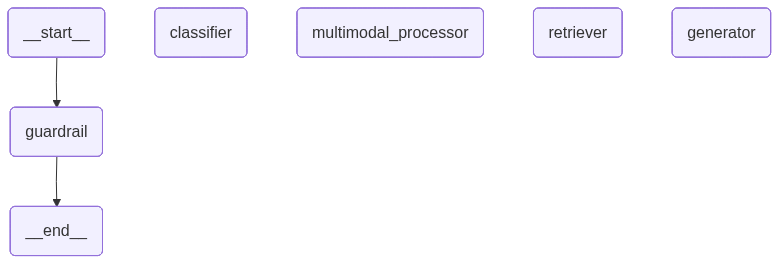

✅ Workflow diagram successfully rendered natively!


In [14]:
from IPython.display import Image, display

print("🕸️ Attempting state machine graph visualization...")

# Try grabbing from the compiled application instance (Modern LangGraph API standard)
if hasattr(app, "get_graph"):
    try:
        # Get the graph layout and request its Mermaid image representation
        graph_img = app.get_graph().draw_mermaid_png()
        display(Image(graph_img))
        print("✅ Workflow diagram successfully rendered natively!")
    except Exception as e:
        print(f"⚠️ Native image rendering failed (Graphviz/PyGraphviz dependencies might be missing): {e}")
        # Fallback to printing the raw Mermaid markdown sequence so you can view it visually
        if hasattr(app.get_graph(), "draw_mermaid"):
            print("\n📋 Copy-paste this text into a Mermaid viewer (like mermaid.live) to view your topology:")
            print(app.get_graph().draw_mermaid())
            
# Backwards compatibility check
elif hasattr(workflow, "get_graph"):
    try:
        graph_img = workflow.get_graph().draw_mermaid_png()
        display(Image(graph_img))
    except Exception:
        print(workflow.get_graph().draw_mermaid())

else:
    # Definitive manual representation if your build environment prevents code-based plotting
    print("\n❌ Environment code hooks skipped. Here is your explicit pipeline layout in Markdown:")
    print("""
    ```mermaid
    graph TD
        UserQuery([User Input]) --> guardrail[Node: Guardrail]
        guardrail -- Is Safe? No --> generator[Node: Gemma Generator]
        guardrail -- Is Safe? Yes --> classifier[Node: Risk Classifier]
        
        classifier -- Risk: Emergency --> generator
        classifier -- Risk: Safe/Routine --> multimodal[Node: Multimodal Processing]
        
        multimodal --> retriever[Node: Vector Search DB]
        retriever --> generator
        generator --> EndNode([Final Response Context + Disclaimer])
    ```
    """)

In [ ]:
import os
from PIL import Image

def start_medigemma_session():
    print("\n" + "="*60)
    print("🏥 MEDIGEMMA INTERACTIVE OFFLINE SESSION STARTED")
    print("Type 'exit' or 'quit' to terminate the assistant loop.")
    print("="*60 + "\n")
    
    while True:
        # 1. Capture user text input
        user_input = input("\n👤 Patient/Medic: ")
        if user_input.strip().lower() in ['exit', 'quit']:
            print("👋 Closing session. Stay safe!")
            break
            
        if not user_input.strip():
            continue
            
        # 2. Capture optional image path input
        image_obj = None
        img_path = input("📎 Path to medical image/file (Optional, press Enter to skip): ").strip()
        
        if img_path:
            # Strip outer quotes if a user drags and drops a file into the terminal
            img_path = img_path.strip("'\"")
            if os.path.exists(img_path):
                try:
                    image_obj = Image.open(img_path)
                    print(f"✅ Loaded attached image: {os.path.basename(img_path)}")
                except Exception as e:
                    print(f"❌ Failed to parse image layout. Proceeding as text-only. Error: {e}")
            else:
                print("⚠️ Image path not found on disk. Proceeding as text-only.")

        # 3. Package variables into your specific Graph Input State
        session_state = {
            "raw_query": user_input,
            "image_input": image_obj
        }
        
        # 4. Invoke the compiled LangGraph application instance statefully
        try:
            print("\n⚙️ Core graph processing...")
            output_state = app.invoke(session_state)
            
            print("\n" + "-"*50)
            print("🤖 SYSTEM RESPONSE:")
            print("-"*50)
            print(output_state["final_output_with_disclaimer"])
            print("-"*50)
            
        except Exception as err:
            print(f"🚨 An error occurred inside graph execution: {err}")

# Launch the shell engine
# start_medigemma_session()